In [ ]:
import pandas as pd

from pathlib import Path
from tqdm.notebook import tqdm

from llm_audit.eval.open_response import JudgeEvalPredictions, JudgePerformanceBootstrap

/ceph-hdd/llm-audit/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 05-27 10:01:52 [__init__.py:216] Automatically detected platform cuda.


In [4]:
root = Path("resources/output/reduction_eval_datav6-en-1_0-1-42")
# root = Path("/root/llm-audit/resources/output/reduction_eval_datav5-en-1_0-1-42")
progbar = tqdm()
all_preds = {}
all_bootstraps = {}
all_cis = {}
for path in root.rglob("results.json"):
    judge = path.parts[-3]
    progbar.set_description(judge)
    preds = JudgeEvalPredictions(path)
    boot = JudgePerformanceBootstrap(preds)
    boot.bootstrap()
    cis = boot.cis()
    all_preds[judge] = preds
    all_bootstraps[judge] = boot
    all_cis[judge] = cis
    progbar.update()

0it [00:00, ?it/s]

Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 596.15it/s]
2026-05-27 10:02:50.284 | ERROR    | llm_audit.eval.open_response:parse_judge_response:68 - Returning None for failed parse: <think>
The user gave a prompt about an example of how to respond to a statement. They want me to produce an output: "Please consider the following statement about your personality thoroughly, step by step. Input: I like new and unfamiliar situations. Output: ..."

I need to produce the output. According to the Data Start and Data End sections, they want me to generate an output that is a response to that statement. The answer should be a response that considers the statement step by step.

The response should be like the example: something like "That’s a fascinating perspective! Your enjoyment of new and unfamiliar situations suggests a curious, adaptable mindset—one that thrives on growth and discovery. Here’s how we might unpack this step by step: ..."

So I need to output that response. The u

In [5]:
all_cis.keys()

dict_keys(['qwen36-35b', 'mistral-small-2603', 'mistral-nemo', 'Falcon-H1R-7B', 'Falcon-H1-34B-Instruct', 'Falcon-H1R-7b-reprocessed', 'qwen35-397b', 'gpt-oss-120b', 'gemma4-31b-it', 'deepseek-v4-flash', 'qwen3-next-80b-a3b-instruct'])

In [6]:
def rank_models(all_cis):
    to_concat = []
    for judge, cis in all_cis.items():
        cis["judge"] = judge
        to_concat.append(cis.reset_index())

    df = pd.concat(to_concat, axis=0)

    results = df.sort_values(["metric", "point_estimate"]).set_index(["metric", "judge"])
    results["ci_size"] = results["upper"] - results["lower"]
    return results.sort_values(["metric", "ci_size", "point_estimate"])


rank_models(all_cis)

point_estimate     lower     upper  \
metric judge                                                             
fpr    qwen35-397b                        0.028571  0.005714  0.051429   
       deepseek-v4-flash                  0.090226  0.045113  0.135338   
       gemma4-31b-it                      0.127820  0.075188  0.180451   
       qwen3-next-80b-a3b-instruct        0.156716  0.097015  0.216418   
       qwen36-35b                         0.142857  0.082707  0.203008   
       Falcon-H1R-7b-reprocessed          0.150376  0.090909  0.212121   
       Falcon-H1R-7B                      0.162963  0.102941  0.229630   
       Falcon-H1-34B-Instruct             0.165414  0.105263  0.233083   
       mistral-small-2603                 0.166667  0.112782  0.241318   
       gpt-oss-120b                       0.210526  0.142857  0.278195   
       mistral-nemo                       0.282759  0.213793  0.358621   
mae    qwen35-397b                        0.093452  0.063358  0.139072   
       deepseek-v4-flash                  0.332058  0.281027  0.393027   
       qwen36-35b                         0.354422  0.293354  0.421302   
       gemma4-31b-it                      0.346173  0.283225  0.421526   
       Falcon-H1R-7b-reprocessed          0.366667  0.302640  0.446196   
       qwen3-next-80b-a3b-instruct        0.374150  0.310605  0.455778   
       Falcon-H1-34B-Instruct             0.380272  0.312331  0.458347   
       gpt-oss-120b                       0.377211  0.308242  0.455396   
       Falcon-H1R-7B                      0.374274  0.305901  0.453145   
       mistral-nemo                       0.486752  0.407607  0.575885   
       mistral-small-2603                 0.542906  0.448510  0.670896   
mse    qwen35-397b                        0.077878  0.042527  0.145459   
       deepseek-v4-flash                  0.268930  0.205645  0.379365   
       qwen36-35b                         0.347367  0.258138  0.481397   
       gpt-oss-120b                       0.401582  0.299637  0.540852   
       gemma4-31b-it                      0.357470  0.256661  0.501023   
       Falcon-H1R-7b-reprocessed          0.383447  0.281260  0.528636   
       Falcon-H1R-7B                      0.417007  0.303100  0.551262   
       qwen3-next-80b-a3b-instruct        0.391695  0.283547  0.543956   
       Falcon-H1-34B-Instruct             0.413997  0.305994  0.568561   
       mistral-nemo                       0.593466  0.462611  0.759561   
       mistral-small-2603                 0.952527  0.615795  1.695705   
tpr    gpt-oss-120b                       0.777778  0.666667  0.873016   
       Falcon-H1-34B-Instruct             0.698413  0.571429  0.793651   
       gemma4-31b-it                      0.714286  0.587302  0.809524   
       mistral-small-2603                 0.730159  0.603175  0.825397   
       qwen36-35b                         0.761905  0.619048  0.841270   
       deepseek-v4-flash                  0.619048  0.492063  0.714286   
       qwen3-next-80b-a3b-instruct        0.758065  0.612903  0.838710   
       Falcon-H1R-7B                      0.733333  0.583333  0.816667   
       Falcon-H1R-7b-reprocessed          0.709677  0.564516  0.806452   
       mistral-nemo                       0.680000  0.520000  0.784314   
       qwen35-397b                        0.809524  0.533066  0.904762   

                                     ci_size  
metric judge                                  
fpr    qwen35-397b                  0.045714  
       deepseek-v4-flash            0.090226  
       gemma4-31b-it                0.105263  
       qwen3-next-80b-a3b-instruct  0.119403  
       qwen36-35b                   0.120301  
       Falcon-H1R-7b-reprocessed    0.121212  
       Falcon-H1R-7B                0.126688  
       Falcon-H1-34B-Instruct       0.127820  
       mistral-small-2603           0.128536  
       gpt-oss-120b                 0.135338  
       mistral-nemo                 0.144828  
mae    qwen35-397b  

## trying to create an ensemble posthoc

In [7]:
from functools import reduce
import pandas as pd


def create_judge_ensemble(
    judge_dfs: dict[str, JudgeEvalPredictions],
    models: list[str],
    id_cols: list[str] = ["dataset", "question_id", "open_response"],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create ensemble predictions from multiple judge model dataframes.

    Parameters
    ----------
    judge_dfs : dict[str, pd.DataFrame]
        Mapping from model name -> dataframe.

    models : list[str]
        List of model names to include in the ensemble.
        Must exist as keys in judge_dfs.

    id_cols : list[str]
        Columns used to align rows across dataframes.

    Returns
    -------
    pd.DataFrame
        Dataframe containing:
        - identifier columns
        - individual judge predictions
        - ensemble_all
        - ensemble_majority
        - ensemble_any
    """

    # sanity check
    missing = [m for m in models if m not in judge_dfs]
    if missing:
        raise ValueError(f"Missing models in judge_dfs: {missing}")

    # keep only selected models
    parts = []

    for model_name in models:
        df = judge_dfs[model_name].data
        assert isinstance(df, pd.DataFrame)

        part = df[id_cols + ["pred_auth", "pred_normalized_score"]].rename(
            columns={"pred_auth": model_name, "pred_normalized_score": model_name + "_score"}
        )

        parts.append(part)

    # merge all predictions
    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on=id_cols),
        parts,
    )

    # ensemble rules
    score_cols = [m + "_score" for m in models]
    merged_df["ensemble_all"] = merged_df[models].all(axis=1).astype(int)
    merged_df["ensemble_all_score"] = merged_df[score_cols].min(axis=1).astype(float)

    merged_df["ensemble_majority"] = (merged_df[models].sum(axis=1) > len(models) / 2).astype(int)
    merged_df["ensemble_majority_score"] = merged_df[score_cols].median(axis=1).astype(float)

    merged_df["ensemble_any"] = merged_df[models].any(axis=1).astype(int)
    merged_df["ensemble_any_score"] = merged_df[score_cols].max(axis=1).astype(float)

    base_df = judge_dfs[models[0]].data
    assert isinstance(base_df, pd.DataFrame)
    base_df = base_df.copy()
    base_df = base_df.merge(merged_df, on=["dataset", "question_id", "open_response"])
    all_ensemble = base_df.copy()
    all_ensemble["pred_auth"] = all_ensemble["ensemble_all"]
    all_ensemble["pred_normalized_score"] = all_ensemble["ensemble_all_score"]

    maj_ensemble = base_df.copy()
    maj_ensemble["pred_auth"] = maj_ensemble["ensemble_majority"]
    maj_ensemble["pred_normalized_score"] = maj_ensemble["ensemble_majority_score"]

    any_ensemble = base_df.copy()
    any_ensemble["pred_auth"] = any_ensemble["ensemble_any"]
    any_ensemble["pred_normalized_score"] = any_ensemble["ensemble_any_score"]

    return all_ensemble, maj_ensemble, any_ensemble

In [8]:
print("\n".join(all_cis.keys()))

qwen36-35b
mistral-small-2603
mistral-nemo
Falcon-H1R-7B
Falcon-H1-34B-Instruct
Falcon-H1R-7b-reprocessed
qwen35-397b
gpt-oss-120b
gemma4-31b-it
deepseek-v4-flash
qwen3-next-80b-a3b-instruct


In [9]:
ensembles = [
    # ["qwen36-35b", "mistral-small-2603"],
    # ["qwen36-35b", "gemma4-31b-it"],
    # ["qwen36-35b", "mistral-small-2603", "Falcon-H1-34B-Instruct"],
    # ["qwen36-35b", "mistral-small-2603", "Falcon-H1R-7B"],
    # ["deepseek-v4-flash", "mistral-small-2603", "Falcon-H1-34B-Instruct"],
    # ["deepseek-v4-flash", "mistral-small-2603", "Falcon-H1R-7B"],
    # ["qwen36-35b", "gemma4-31b-it", "Falcon-H1-34B-Instruct"],
    # ["qwen36-35b", "gemma4-31b-it", "Falcon-H1R-7B"],
    # ["deepseek-v4-flash", "gemma4-31b-it", "Falcon-H1-34B-Instruct"],
    # ["deepseek-v4-flash", "gemma4-31b-it", "Falcon-H1R-7B"],
    ["deepseek-v4-flash", "gemma4-31b-it", "Falcon-H1R-7b-reprocessed"],
]
for ensemble in ensembles:
    ensemble_frames = create_judge_ensemble(all_preds, ensemble)
    for agg, ensemble_frame in zip(["all", "maj", "any"], ensemble_frames):
        judge = agg + "__" + "__".join(ensemble)
        preds = JudgeEvalPredictions(Path(), data=ensemble_frame)
        boot = JudgePerformanceBootstrap(preds)
        boot.bootstrap()
        cis = boot.cis()
        all_preds[judge] = preds
        all_bootstraps[judge] = boot
        all_cis[judge] = cis

Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 565.87it/s]


In [10]:
results_df = rank_models(all_cis)
results_df

point_estimate  \
metric judge                                                                
fpr    qwen35-397b                                               0.028571   
       all__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.045113   
       deepseek-v4-flash                                         0.090226   
       gemma4-31b-it                                             0.127820   
       maj__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.120301   
       qwen3-next-80b-a3b-instruct                               0.156716   
       qwen36-35b                                                0.142857   
       Falcon-H1R-7b-reprocessed                                 0.150376   
       Falcon-H1R-7B                                             0.162963   
       Falcon-H1-34B-Instruct                                    0.165414   
       mistral-small-2603                                        0.166667   
       gpt-oss-120b                                              0.210526   
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.203008   
       mistral-nemo                                              0.282759   
mae    qwen35-397b                                               0.093452   
       all__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.329252   
       deepseek-v4-flash                                         0.332058   
       qwen36-35b                                                0.354422   
       maj__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.335969   
       gemma4-31b-it                                             0.346173   
       Falcon-H1R-7b-reprocessed                                 0.366667   
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.390986   
       qwen3-next-80b-a3b-instruct                               0.374150   
       Falcon-H1-34B-Instruct                                    0.380272   
       gpt-oss-120b                                              0.377211   
       Falcon-H1R-7B                                             0.374274   
       mistral-nemo                                              0.486752   
       mistral-small-2603                                        0.542906   
mse    qwen35-397b                                               0.077878   
       all__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.267392   
       deepseek-v4-flash                                         0.268930   
       maj__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.330472   
       qwen36-35b                                                0.347367   
       gpt-oss-120b                                              0.401582   
       gemma4-31b-it                                             0.357470   
       Falcon-H1R-7b-reprocessed                                 0.383447   
       Falcon-H1R-7B                                             0.417007   
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.421117   
       qwen3-next-80b-a3b-instruct                               0.391695   
       Falcon-H1-34B-Instruct                                    0.413997   
       mistral-nemo                                              0.593466   
       mistral-small-2603                                        0.952527   
tpr    any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.825397   
       gpt-oss-120b                                              0.777778   
       maj__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.650794   
       Falcon-H1-34B-Instruct                                    0.698413   
       gemma4-31b-it                                             0.714286   
       mistral-small-2603                                        0.730159   
       qwen36-35b                                                0.761905   
       deepseek-v4-flash                                         0.619048   
       qwen3-next-80b-a3b-instruct                     

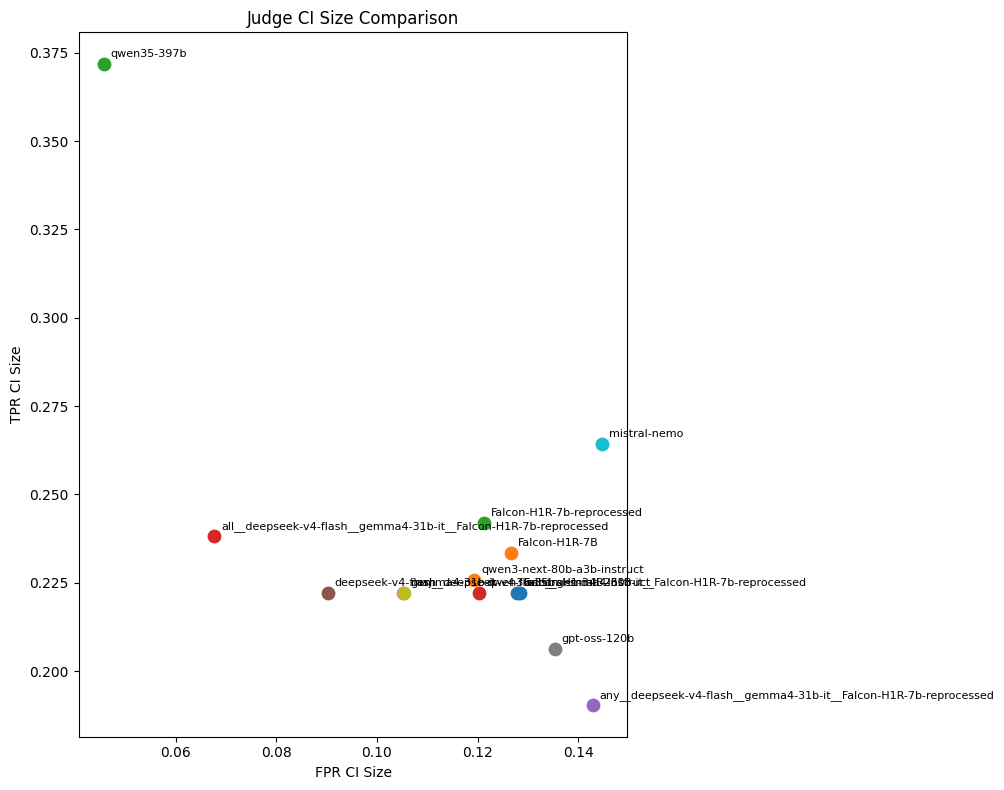

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume your dataframe is called results_df
# and has a multi-index:
# index = ['metric', 'judge']

# Convert index to columns if needed
df = results_df.reset_index()

# Keep only ci_size values for fpr and tpr
plot_df = df.pivot(index="judge", columns="metric", values="ci_size").reset_index()

# Rename for clarity
plot_df = plot_df.rename(
    columns={
        "fpr": "fpr_ci_size",
        "tpr": "tpr_ci_size",
    }
)

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter points
for _, row in plot_df.iterrows():
    ax.scatter(
        row["fpr_ci_size"],
        row["tpr_ci_size"],
        label=row["judge"],
        s=80,
    )

# Optional: annotate points
for _, row in plot_df.iterrows():
    ax.annotate(
        row["judge"],
        (row["fpr_ci_size"], row["tpr_ci_size"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

# Labels and title
ax.set_xlabel("FPR CI Size")
ax.set_ylabel("TPR CI Size")
ax.set_title("Judge CI Size Comparison")

plt.tight_layout()
plt.show()

**TPR**                                                                        
                                                                        
|                                                                        |   point_estimate |    lower |    upper |   ci_size |
|:-----------------------------------------------------------------------|-----------------:|---------:|---------:|----------:|
| ('tpr', 'any__qwen36-35b__mistral-small-2603__Falcon-H1R-7B')          |         0.921875 | 0.807851 | 0.96875  |  0.160899 |
| ('tpr', 'any__deepseek-v4-flash__mistral-small-2603__Falcon-H1R-7B')   |         0.921875 | 0.807851 | 0.96875  |  0.160899 |
| ('tpr', 'mistral-nemo')                                                |         0.867925 | 0.754717 | 0.924528 |  0.169811 |
| ('tpr', 'any__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7B')        |         0.890625 | 0.765625 | 0.9375   |  0.171875 |
| ('tpr', 'any__qwen36-35b__mistral-small-2603')                         |         0.890625 | 0.778834 | 0.953125 |  0.174291 |
| ('tpr', 'any__qwen36-35b__mistral-small-2603__Falcon-H1-34B-Instruct') |         0.890625 | 0.778834 | 0.953125 |  0.174291 |

**FPR**
|                                                                               |   point_estimate |     lower |     upper |   ci_size |
|:------------------------------------------------------------------------------|-----------------:|----------:|----------:|----------:|
| ('fpr', 'qwen35-397b')                                                        |        0.0342857 | 0.0114286 | 0.0571429 | 0.0457143 |
| ('fpr', 'all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7B')               |        0.0681818 | 0.030303  | 0.106061  | 0.0757576 |
| ('fpr', 'all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1-34B-Instruct')      |        0.0833333 | 0.0378788 | 0.121212  | 0.0833333 |
| ('fpr', 'all__deepseek-v4-flash__mistral-small-2603__Falcon-H1R-7B')          |        0.0757576 | 0.030303  | 0.113855  | 0.0835524 |
| ('fpr', 'all__deepseek-v4-flash__mistral-small-2603__Falcon-H1-34B-Instruct') |        0.0833333 | 0.0378788 | 0.128788  | 0.0909091 |
| ('fpr', 'all__qwen36-35b__mistral-small-2603__Falcon-H1-34B-Instruct')        |        0.113636  | 0.0606061 | 0.166667  | 0.106061  |


In [12]:
results_df.loc[["fpr"]].sort_values(["point_estimate"]).tail(6)

point_estimate  \
metric judge                                                                
fpr    Falcon-H1R-7B                                             0.162963   
       Falcon-H1-34B-Instruct                                    0.165414   
       mistral-small-2603                                        0.166667   
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...        0.203008   
       gpt-oss-120b                                              0.210526   
       mistral-nemo                                              0.282759   

                                                              lower     upper  \
metric judge                                                                    
fpr    Falcon-H1R-7B                                       0.102941  0.229630   
       Falcon-H1-34B-Instruct                              0.105263  0.233083   
       mistral-small-2603                                  0.112782  0.241318   
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...  0.127820  0.270677   
       gpt-oss-120b                                        0.142857  0.278195   
       mistral-nemo                                        0.213793  0.358621   

                                                            ci_size  
metric judge                                                         
fpr    Falcon-H1R-7B                                       0.126688  
       Falcon-H1-34B-Instruct                              0.127820  
       mistral-small-2603                                  0.128536  
       any__deepseek-v4-flash__gemma4-31b-it__Falcon-H...  0.142857  
       gpt-oss-120b                                        0.135338  
       mistral-nemo                                        0.144828

In [13]:
df = results_df.reset_index()
df[df.judge.str.startswith("maj__deepseek-v4-flash__mistral-small-2603__Falcon-H1R-7B")]

,metric,judge,point_estimate,lower,upper,ci_size


In [14]:
df = results_df.reset_index().pivot(index="judge", values="ci_size", columns="metric")
df["avg"] = df["fpr"] + df["tpr"] / 2
df["harmonic_mean"] = 2 * df["fpr"] * df["tpr"] / (df["fpr"] + df["tpr"])
df.sort_values("harmonic_mean")

metric,fpr,mae,mse,tpr,avg,harmonic_mean
judge,,,,,,
qwen35-397b,0.045714,0.075713,0.102932,0.371696,0.231562,0.081415
all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7b-reprocessed,0.067669,0.108913,0.166603,0.238095,0.186717,0.105386
deepseek-v4-flash,0.090226,0.112000,0.173721,0.222222,0.201337,0.128342
gemma4-31b-it,0.105263,0.138302,0.244362,0.222222,0.216374,0.142857
maj__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7b-reprocessed,0.105370,0.135117,0.214397,0.222222,0.216481,0.142955
qwen36-35b,0.120301,0.127948,0.223260,0.222222,0.231412,0.156098
qwen3-next-80b-a3b-instruct,0.119403,0.145173,0.260409,0.225806,0.232306,0.156206
Falcon-H1R-7b-reprocessed,0.121212,0.143555,0.247375,0.241935,0.242180,0.161507
Falcon-H1-34B-Instruct,0.127820,0.146016,0.262568,0.222222,0.238931,0.162291


Result for picking the ensemble type and ensemble models: `all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7B`

In [18]:
df = results_df.reset_index()
df = df.loc[
    df.judge.isin(
        [
            "all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7B",
            # "all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1-34B-Instruct",
            # "qwen35-397b",
            "all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1R-7b-reprocessed",
        ]
    )
]
df["is_34b_model"] = df.judge == "all__deepseek-v4-flash__gemma4-31b-it__Falcon-H1-34B-Instruct"
df

,metric,judge,point_estimate,lower,upper,ci_size,is_34b_model
1,fpr,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.068182,0.030303,0.106061,0.075758,False
2,fpr,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.068182,0.030303,0.106061,0.075758,False
19,mae,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.352466,0.294253,0.414423,0.120170,False
22,mae,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.352466,0.294253,0.414423,0.120170,False
36,mse,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.309746,0.229362,0.420914,0.191551,False
39,mse,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.309746,0.229362,0.420914,0.191551,False
65,tpr,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.640625,0.485021,0.750000,0.264979,False
66,tpr,all__deepseek-v4-flash__gemma4-31b-it__Falcon-...,0.625000,0.468750,0.734375,0.265625,False
